In [1]:
# LIBRARY IMPORTS

import os
import glob
import pickle
import random

import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

import cupy as cp

from tqdm import tqdm

import importlib.util
from pathlib import Path

import os, ipykernel
print("PID:", os.getpid())
print("Kernel file:", ipykernel.get_connection_file())

PID: 2633327
Kernel file: /run/user/665511/jupyter/runtime/kernel-v35a95ba9cc30c77c61446a1b15a61f11b36afaabd.json


In [ ]:
# IMPORT PCA DIM REDUCTION FUNCTION

"""
    Input:
        Features: real-valued tensor with shape
            [n_data_samples, n_tx_ant * n_prbs * 12, n_dmrs_symbols].

    Output:
        2D (complex) map for all samples with shape:
            [D_prime=2, n_data_samples].
    """

module_path = Path("/home/bsc26f18/DeviceClassCharting/device-classification-5g/Closed_set_RFFI/pca_dimensionality_reduction.py")

spec = importlib.util.spec_from_file_location("pca_dimensionality_reduction", module_path)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

dim_red_pca = mod.dim_red_pca
print("Loaded:", dim_red_pca.__name__)

In [2]:
# CONFIG FILE FOR IMPORTING PICKLE FILES
# HAS RANDOM SEED, EXECUTE ONCE


DATASET_BASE = '/scratch/bsc26f18/datasets/device_classification_2025_11_15'
SPLIT = 'all'  # 'training' or 'testing', or 'all'

# Choose which device folders (labels) to sample from.
LABELS = ['iPhone14Pro_black', 'iPhone14Pro_gold', 'iPhone16e', 'OnePlusNord', 'pixel7', 'sgs23']

# How many pickle files to load per label (keep it small for interactive plotting).
N_PICKLES_PER_LABEL = 100

# relevant if SELECTION_STRATEGY == 'n_sorted_after_m_samples'
START_OFFSET = 1000
N_CONSECTUIVE_RANDOM_BATCHES = 10

# Selection strategy: 'first' (sorted filenames) or 'random', or 'n_sorted_after_m_samples'
SELECTION_STRATEGY = 'n_sorted_after_m_samples'
MY_RNG = random.Random(10)

n_dmrs_symbols = 3
n_prbs = 273
n_tx_ant = 1
n_rx_ant_per_oru = 4
n_orus = 4

In [3]:
# EXTRACT FILES AND COMPUTE FEATURES

debug = False

#features_list = np.zeros((len(LABELS), n_tx_ant * n_prbs * 12), dtype=np.complex64)
labels_list = []
pre_rng_idx_list = np.zeros((len(LABELS), N_PICKLES_PER_LABEL), dtype=np.int32)
consectutive_features_at_random_offset_list = np.zeros((len(LABELS), N_CONSECTUIVE_RANDOM_BATCHES, n_tx_ant * n_prbs * 12), dtype=np.complex64)
label_random_start_offsets = np.zeros((len(LABELS), N_CONSECTUIVE_RANDOM_BATCHES), dtype=np.int32)

# make sure that seed is only set once
start_offset_seed = random.Random(1)

for label_idx, label in enumerate(LABELS):

    # LIST PICKLE FOR LABEL
    pattern = os.path.join(DATASET_BASE, SPLIT, label, '*.pickle')
    print("Pattern: ", pattern)
    paths = glob.glob(pattern)
    n_data_samples = len(paths)
    # Using float because there is no double type in Python. Float has already double precision.
    sorted_paths = sorted(paths, key=lambda p: float(os.path.basename(p).split('_')[0]))

    if debug:
        sorted_keys = [float(os.path.basename(p).split('_')[0]) for p in sorted_paths]
        assert all(a<=b for a,b in zip(sorted_keys[:-1], sorted_keys[1:])), "Paths are not sorted by timestamp!"
        print("\n".join(sorted_paths[1000:1050]))

    chosen_random_start_offsets = start_offset_seed.sample(range(len(paths)-N_PICKLES_PER_LABEL), k=N_CONSECTUIVE_RANDOM_BATCHES)
    label_random_start_offsets[label_idx] = chosen_random_start_offsets
    
    for batch_idx in range(N_CONSECTUIVE_RANDOM_BATCHES):

            n = N_PICKLES_PER_LABEL
            strategy = SELECTION_STRATEGY
            m = chosen_random_start_offsets[batch_idx]
            rng = MY_RNG

            if n is None or n >= len(paths):
                chosen_indices = list(range(len(paths)))
            elif strategy == 'first':
                chosen_indices = list(range(n))
            elif strategy == 'n_sorted_after_m_samples':
                chosen_indices = list(range(n+m))[m:]
            elif strategy == 'random':
                chosen_indices = rng.sample(range(len(paths)), k=n)
            else:
                raise ValueError(f"Unknown strategy: {strategy}")

            chosen_paths = [paths[i] for i in chosen_indices]

            print(f"Label={label}: found {len(sorted_paths)} pickles, selected {len(chosen_paths)}")



            n_subset = N_PICKLES_PER_LABEL

            #H = np.zeros((n_data_samples, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols), dtype=np.complex64)
            noise_var = np.zeros((n_subset,n_orus), dtype=np.float32)
            sample_timestamps = np.zeros((n_subset), dtype=np.float64)

            print("Processing CSI estimates")

            t = tqdm(total=n_subset)
            H_list = np.zeros((n_subset, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols), dtype=np.complex64)
            # read in all pickle files and store data to associated variables
            for idx in range(len(chosen_paths)):
                t.update()  
                with open(chosen_paths[idx], 'rb') as file:
                    x = pickle.load(file)

                # h_sample = x['ch_est']
                h_sample = x['ch_est'] # N_ORU x Rx ant x layer x frequency x time
                H = np.squeeze(np.array(h_sample), axis=1)    # np.array should make a copy, slice assignment should also do the copy on itself
                assert H.shape == (n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols), f"H shape is {H.shape} but should be ({n_orus}, {n_rx_ant_per_oru}, {n_tx_ant}, {n_prbs*12}, {n_dmrs_symbols})"
                H_list[idx, :, :, :, :, :] = H

                # H[idx, :, :, :, :, :] = np.take(np.squeeze(np.array(h_sample), axis=1), indices=[0,2], axis=0)    
                # noise_var[idx, 0] = x['noise_var_dB'][0] # @TODO: here is a bug in the PyAerial Notebook! It should be the noise var from two O-RUs
                # noise_var[idx, :] = np.squeeze(np.array(x['noise_var_dB']))
                # noise_var[idx, :] = np.take(np.squeeze(np.array(x['noise_var_dB'])), indices=[0,2], axis=0)    
                # we also have in x the keys 'start_prb', 'num_prbs' but we use all 273 PRBs all of the times

                
                pre_rng_idx_list[label_idx, idx] = chosen_indices[idx]

                timestamp_str = float(os.path.basename(chosen_paths[idx]).split('_')[0])
                sample_timestamps[idx] = timestamp_str

            # Ensure tqdm finishes its line before subsequent prints.
            t.close()
            print("")

            assert H.shape == (n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols), f"H shape is {H.shape} but should be ({n_orus}, {n_rx_ant_per_oru}, {n_tx_ant}, {n_prbs*12}, {n_dmrs_symbols})"
            assert H_list.shape == (n_subset, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols), f"H_list shape is {H_list.shape} but should be ({n_subset}, {n_orus}, {n_rx_ant_per_oru}, {n_tx_ant}, {n_prbs*12}, {n_dmrs_symbols})"

            #assert all(n_data_samples == sorted_paths_len_list[i] for i in range(len(sorted_paths_len_list))), "Number of data samples is not the same for all labels"
            #H_list_stacked = np.stack(H_list, axis=0) # [len(label_list)*N_PICKLES_PER_LABEL, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols]
            #assert H_list_stacked.shape[0] == len(label_list) * n_data_samples
            #H_all = np.reshape(H_list_stacked, [len(label_list), n_data_samples, *H_list_stacked.shape[1:]]) # H_all has dimension: [len(label_list), N_PICKLES_PER_LABEL, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols]

            
            # COMPUTE FEATURES

            #elif self.feature_type == 'obfuscation':
            # H_list has dimension: [n_data_samples, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols]
            print("Reshape H matrix")
            H_ = np.transpose(H_list, [3,4,5,0,1,2])
            assert H_.shape == (n_tx_ant, n_prbs*12, n_dmrs_symbols, N_PICKLES_PER_LABEL, n_orus, n_rx_ant_per_oru), f"H_ shape is {H_.shape} but should be ({n_subset}, {n_tx_ant}, {n_prbs*12}, {n_dmrs_symbols}, {n_orus}, {n_rx_ant_per_oru})"
            H_ = np.reshape(H_, [n_tx_ant*n_prbs*12*n_dmrs_symbols, -1])
            # H_ is [n_tx_ant * n_prbs * 12 * n_dmrs_symbols, n_data_samples * n_orus * n_rx_ant_per_oru]
            assert H_.shape == (n_tx_ant * n_prbs * 12 * n_dmrs_symbols, N_PICKLES_PER_LABEL*n_orus * n_rx_ant_per_oru)

            print('Normalize each channel vector')
            H_ = H_ / np.linalg.norm(H_, axis=-1, keepdims=True)

            print(f"H_ shape: {H_.shape}")

            H_mag = np.abs(H_)

            print("Compute SVD")
            U, S, Vh = np.linalg.svd(H_mag, full_matrices=False, compute_uv=True, hermitian=False)
            # keep type complex64 to ensure the result is purely real (check phase)
            principal_singular_vector = U[:,0].astype(np.complex64)
    
            print(f"U shape: {U.shape}")
            print(f"principal_singular_vector shape: {principal_singular_vector.shape}")

            print("Reshape features")
            # principal_singular_vector has dims [n_tx_ant * n_prbs * 12 * n_dmrs_symbols]
            features = np.reshape(principal_singular_vector, [n_tx_ant * n_prbs * 12, n_dmrs_symbols])
            # features has dims [n_tx_ant * n_prbs * 12, n_dmrs_symbols]
            assert features.shape == (n_tx_ant * n_prbs * 12, n_dmrs_symbols)

            print("Flattening features over DMRS symbols")
            # FLATTEN FEATURES TO USE AVERAGE OVER DMRS SYMBOLS BECAUSE THE CHANGE IS ALMOST NON-EXISTENT
            features = np.mean(features, axis=-1, keepdims=False)
            print(f"features_flat: {features.shape}")
            assert features.shape == (n_tx_ant * n_prbs * 12,), "features_flat shape mismatch"

            #features_list[label_idx] = features
            #assert features_list.shape == (len(LABELS), n_tx_ant * n_prbs * 12), "features_list shape mismatch"

            print("Adding feature vector to consectutive_features_at_random_offset_list")
            consectutive_features_at_random_offset_list[label_idx, batch_idx] = features
        
    labels_list.append(label_idx)


features_list = consectutive_features_at_random_offset_list
assert features_list.shape == (len(LABELS), N_CONSECTUIVE_RANDOM_BATCHES, n_tx_ant * n_prbs * 12), "features_list shape mismatch"

print("Converting to global_features")
global_features = np.reshape(features_list, [-1, n_tx_ant * n_prbs * 12])
# global_features has dims [len(LABELS), n_tx_ant * n_prbs * 12]
assert global_features.shape == (len(LABELS)*N_CONSECTUIVE_RANDOM_BATCHES, n_tx_ant * n_prbs * 12), "global_features shape mismatch"

print("Creating global_lables")
# create local device IDs for identification later in the plot
device_ids = np.arange(len(LABELS))
global_labels = np.repeat(device_ids, N_CONSECTUIVE_RANDOM_BATCHES)
# global_labels has dims [len(LABELS) * N_CONSECTUIVE_RANDOM_BATCHES]


print("Done!")

Pattern:  /scratch/bsc26f18/datasets/device_classification_2025_11_15/all/iPhone14Pro_black/*.pickle


Label=iPhone14Pro_black: found 16853 pickles, selected 100
Processing CSI estimates


100%|██████████| 100/100 [00:04<00:00, 22.89it/s]



Reshape H matrix
Normalize each channel vector
H_ shape: (9828, 1600)
Compute SVD
U shape: (9828, 1600)
principal_singular_vector shape: (9828,)
Reshape features
Flattening features over DMRS symbols
features_flat: (3276,)
Adding feature vector to consectutive_features_at_random_offset_list
Label=iPhone14Pro_black: found 16853 pickles, selected 100
Processing CSI estimates


100%|██████████| 100/100 [00:03<00:00, 32.31it/s]


...


Reshape H matrix
Normalize each channel vector
H_ shape: (9828, 1600)
Compute SVD
U shape: (9828, 1600)
principal_singular_vector shape: (9828,)
Reshape features
Flattening features over DMRS symbols
features_flat: (3276,)
Adding feature vector to consectutive_features_at_random_offset_list
Label=sgs23: found 18357 pickles, selected 100
Processing CSI estimates


100%|██████████| 100/100 [00:00<00:00, 280.46it/s]



Reshape H matrix
Normalize each channel vector
H_ shape: (9828, 1600)
Compute SVD
U shape: (9828, 1600)
principal_singular_vector shape: (9828,)
Reshape features
Flattening features over DMRS symbols
features_flat: (3276,)
Adding feature vector to consectutive_features_at_random_offset_list
Label=sgs23: found 18357 pickles, selected 100
Processing CSI estimates


100%|██████████| 100/100 [00:03<00:00, 29.64it/s]



Reshape H matrix
Normalize each channel vector
H_ shape: (9828, 1600)
Compute SVD
U shape: (9828, 1600)
principal_singular_vector shape: (9828,)
Reshape features
Flattening features over DMRS symbols
features_flat: (3276,)
Adding feature vector to consectutive_features_at_random_offset_list
Converting to global_features
Creating global_lables
Done!


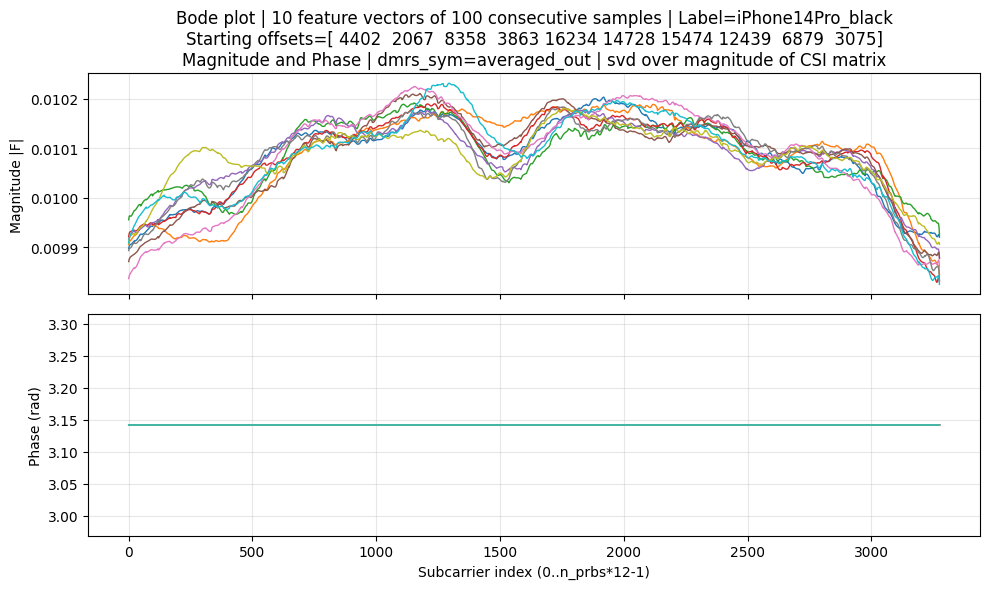

Plotted frequency bins: 0..3275


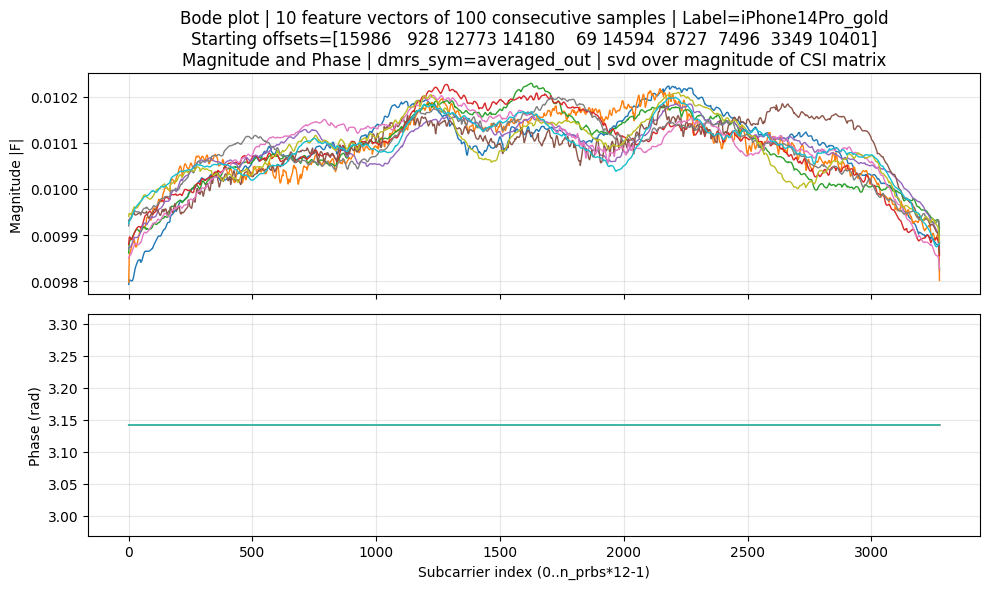

Plotted frequency bins: 0..3275


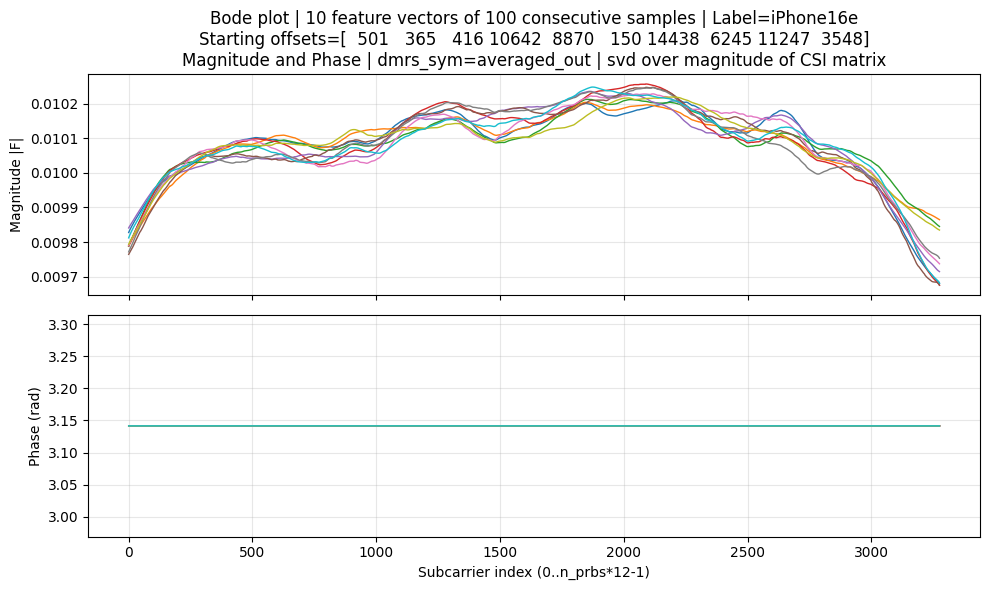

Plotted frequency bins: 0..3275


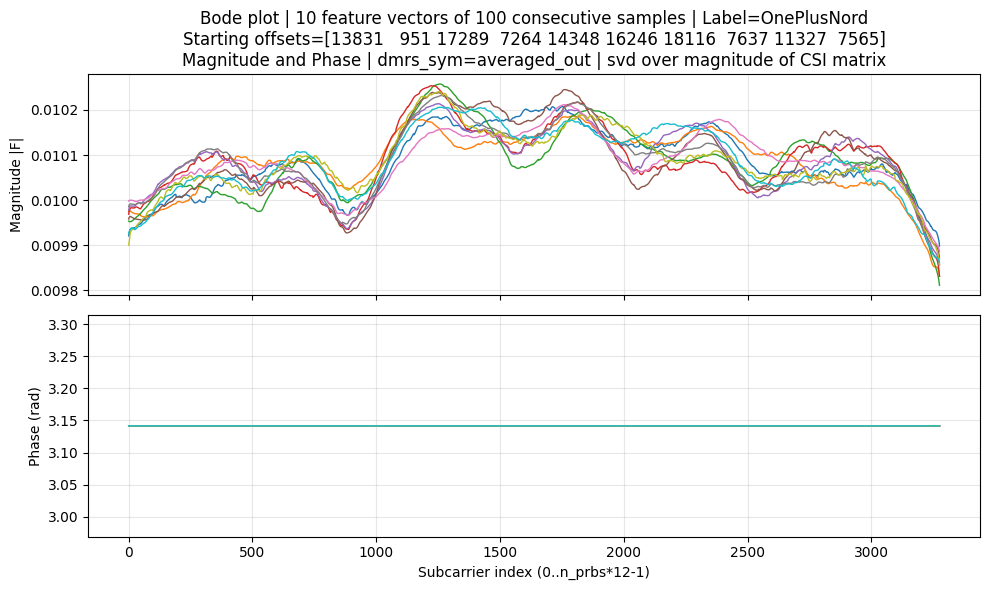

Plotted frequency bins: 0..3275


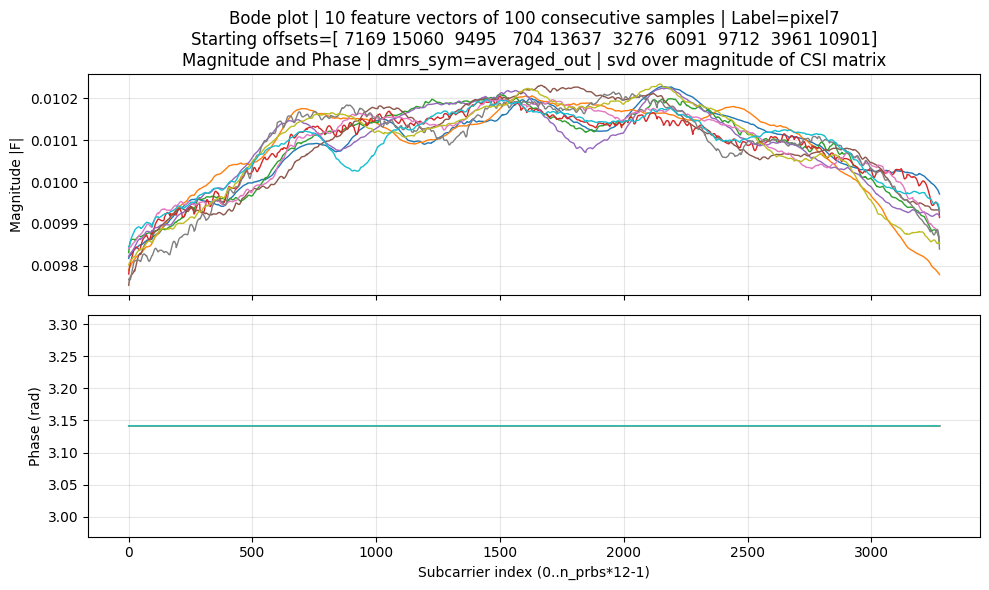

Plotted frequency bins: 0..3275


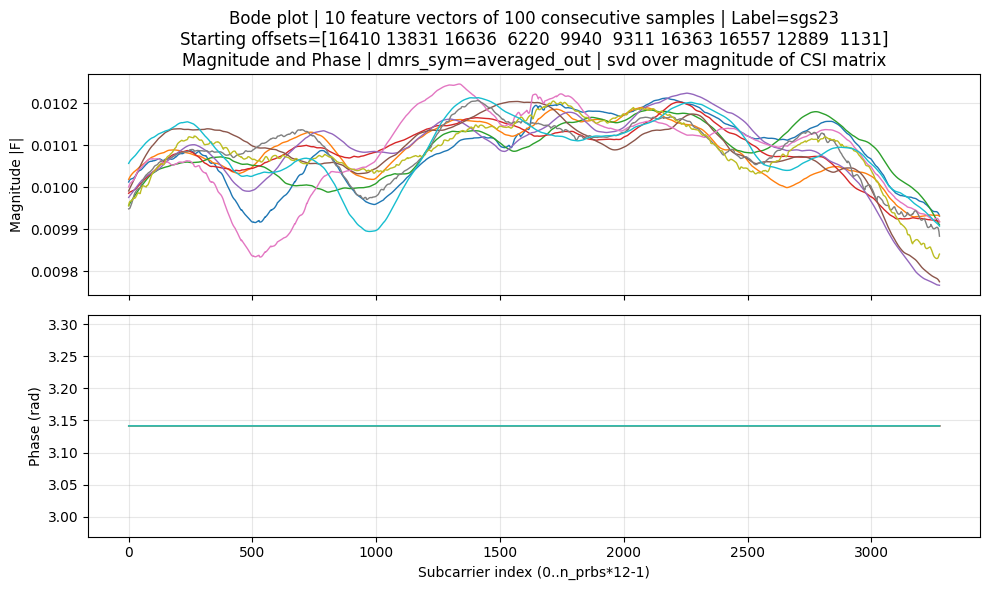

Plotted frequency bins: 0..3275


In [19]:
# --------------------
# Bode-style magnitude + phase for fingerprints
# --------------------

selection_title = 'random' if SELECTION_STRATEGY == 'random' else 'consecutive'


# Frequency-bin slice (index range, not physical Hz)
freq_start_bode = 0
freq_end_bode = None  # set to an int to zoom

eps = 1e-6

for label_idx, label in enumerate(LABELS):

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    for start_offset in range(N_CONSECTUIVE_RANDOM_BATCHES):

        #feature_vec = global_features[label_idx]
        feature_vec = features_list[label_idx, start_offset]

        phase = np.angle(feature_vec)
        mag = np.abs(feature_vec)

        phase = np.unwrap(phase)

        fs = 0
        fe = feature_vec.shape[0]

        if fe <= fs:
            raise ValueError(f"Invalid bode slice: fs={fs}, fe={fe}")

        f_bins = np.arange(fs, fe)

        mag_slice = mag[fs:fe]
        phase_slice = phase[fs:fe]

        mag_ylabel = 'Magnitude |F|'

        axes[0].plot(f_bins, mag_slice, linewidth=1.0)
        axes[1].plot(f_bins, phase_slice, linewidth=1.0)
        
    
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylabel(mag_ylabel)
    axes[0].set_title(
        f"Bode plot | {N_CONSECTUIVE_RANDOM_BATCHES} feature vectors of {N_PICKLES_PER_LABEL} {selection_title} samples | Label={label}\n"
        f"Starting offsets={label_random_start_offsets[label_idx]}\n"
        f"Magnitude and Phase | dmrs_sym=averaged_out | svd over magnitude of CSI matrix"
    )

    #plt.legend(np.arange(N_PICKLES_PER_LABEL))

    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylabel('Phase (rad)')
    axes[1].set_xlabel('Subcarrier index (0..n_prbs*12-1)')

    #axes[0].legend(loc='upper right', bbox_to_anchor=(1.25, 1.0))

    plt.tight_layout()

    out_name = (
        f"bode_features_{label}_{N_CONSECTUIVE_RANDOM_BATCHES}_features_of_{N_PICKLES_PER_LABEL}_{selection_title}_samples_dmrs_averaged.png"
    )
    plt.savefig(out_name, dpi=300, bbox_inches='tight')
    plt.show()

    #print('Rec pickle:', sample_rec_arr[label_idx*N_PICKLES_PER_LABEL+sample_i][2])
    #print('H_sel_local.shape:', H_sel_local.shape, '(freq_bins, dmrs_symbols)')
    print(f'Plotted frequency bins: {fs}..{fe-1}')


In [6]:
# COMPUTE DIFFERENT DISTANCE METRICS BETWEEN SAMPLES

def compute_distance_matrices(X=global_features, L2=True, Cosine=True, Chordal=True, Bures=True):
    """Compute several pairwise distance matrices from feature matrix X [N,F]."""

    #N = X.shape[0]
    distances = {}

    # --- L2 (Euclidean) distance ---
    if L2:
        sq_norms = np.sum(np.abs(X)**2, axis=1, keepdims=True)
        D_l2 = sq_norms + sq_norms.T - 2 * np.real(X @ X.conj().T)
        D_l2 = np.sqrt(np.maximum(D_l2, 0.0))
        distances['L2'] = D_l2
        print(f"L2 distance shape: {D_l2.shape}")

    G = X @ X.conj().T

    # --- Cosine distance ---
    if Cosine:
        norms = np.sqrt(np.sum(np.abs(X)**2, axis=1, keepdims=True))
        cos_sim = np.abs(G) / (norms @ norms.T)
        D_cos = 1.0 - cos_sim
        D_cos = np.maximum(D_cos, 0.0)
        distances['Cosine'] = D_cos


    abs_cos_sim = np.abs(G) / (norms @ norms.T)

    # --- Chordal distance ---
    # For unit-norm vectors on the complex sphere, chordal distance is:
    #   d_chordal(x, y) = sqrt(1 - |<x,y>|^2 / (||x||^2 ||y||^2))
    if Chordal:
        D_chordal = np.sqrt(np.maximum(1.0 - abs_cos_sim**2, 0.0))
        distances['Chordal'] = D_chordal

    # --- Bures-Wasserstein distance ---
    # For unit-norm vectors on the complex sphere, Bures-Wasserstein distance is:
    #   d_bures(x, y) = sqrt(1 - |<x,y>| / (||x|| ||y||))
    if Bures:
        D_bures = np.sqrt(np.maximum(1.0 - abs_cos_sim, 0.0))
        distances['Bures'] = D_bures

    return distances

In [7]:
# EXTRACT INTRA- AND INTER-CLASS DISTANCES

def extract_class_distances(D, global_labels, labels):
    """
    Given a [N, N] pairwise distance matrix, extract:
      - intra_distances: dict {label: 1D array of within-class distances}
      - inter_distances: dict {(label_i, label_j): 1D array of between-class distances}
    Only upper-triangle entries are used (avoids double-counting and self-distances).
    """
    intra_distances = {}
    inter_distances = {}

    for i, li in enumerate(labels):
        mask_i = (global_labels == i)
        
        # Intra-class: upper triangle of the D[mask_i][:, mask_i] block
        D_block = D[np.ix_(mask_i, mask_i)]
        triu_idx = np.triu_indices(D_block.shape[0], k=1)
        intra_distances[li] = np.real(D_block[triu_idx])

        for j, lj in enumerate(labels):
            if j <= i:
                continue
            mask_j = (global_labels == j)
            # Inter-class: full rectangular block (no symmetry to exploit)
            inter_distances[(li, lj)] = np.real(D[np.ix_(mask_i, mask_j)].ravel())

    return intra_distances, inter_distances

L2 distance shape: (60, 60)


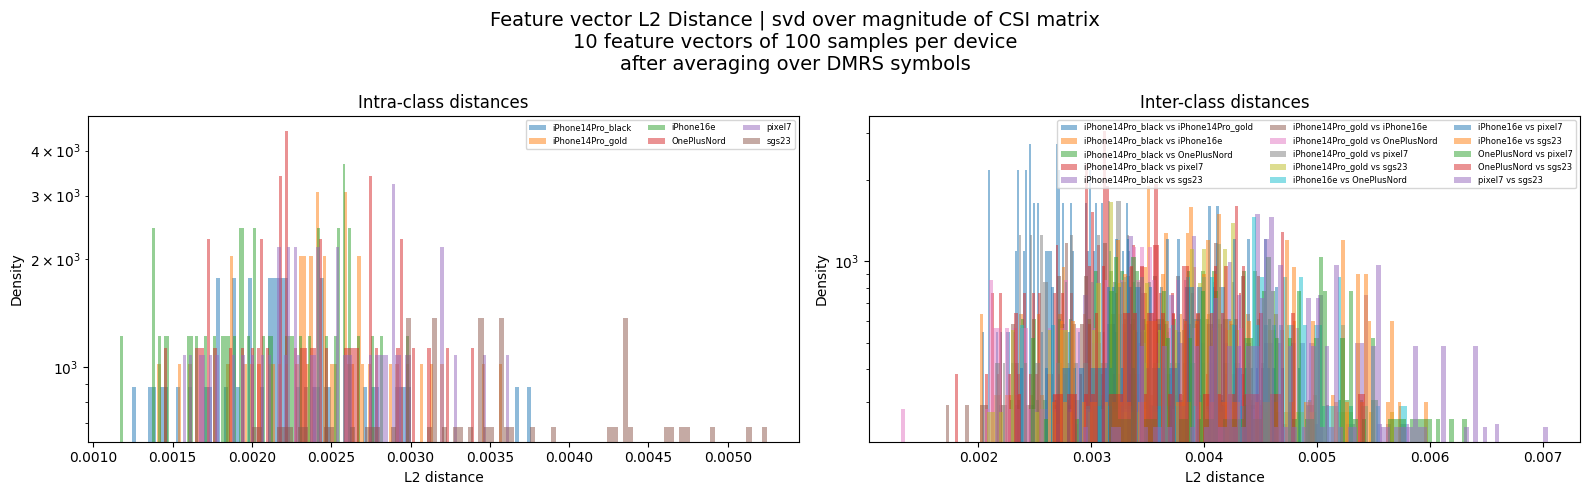

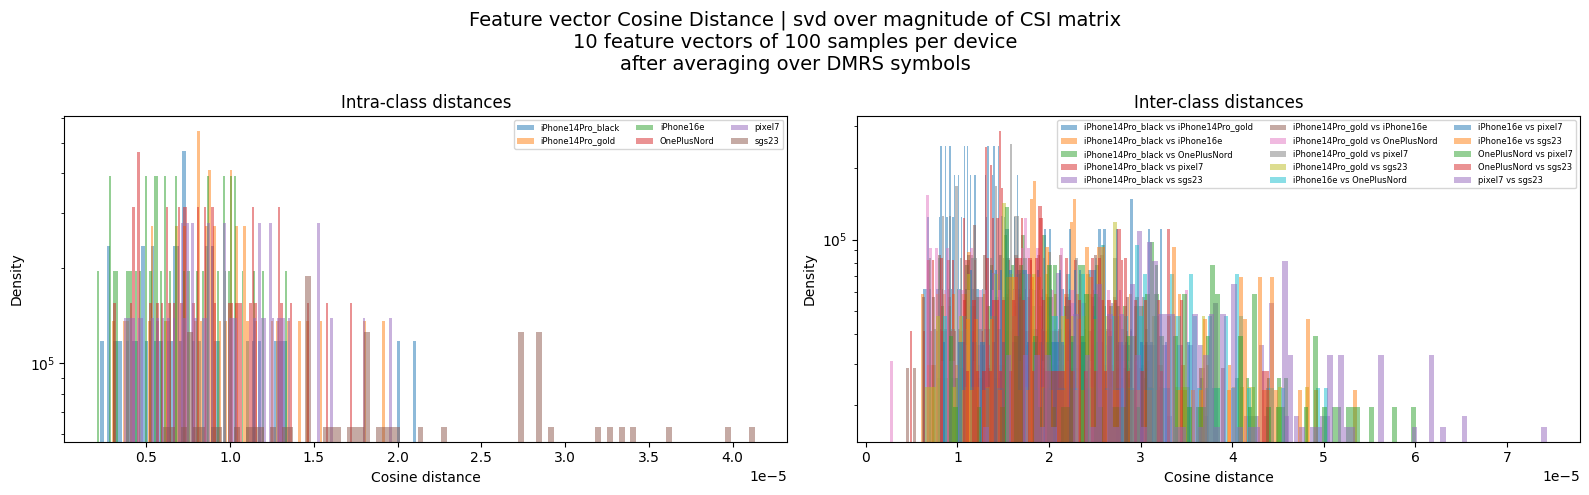

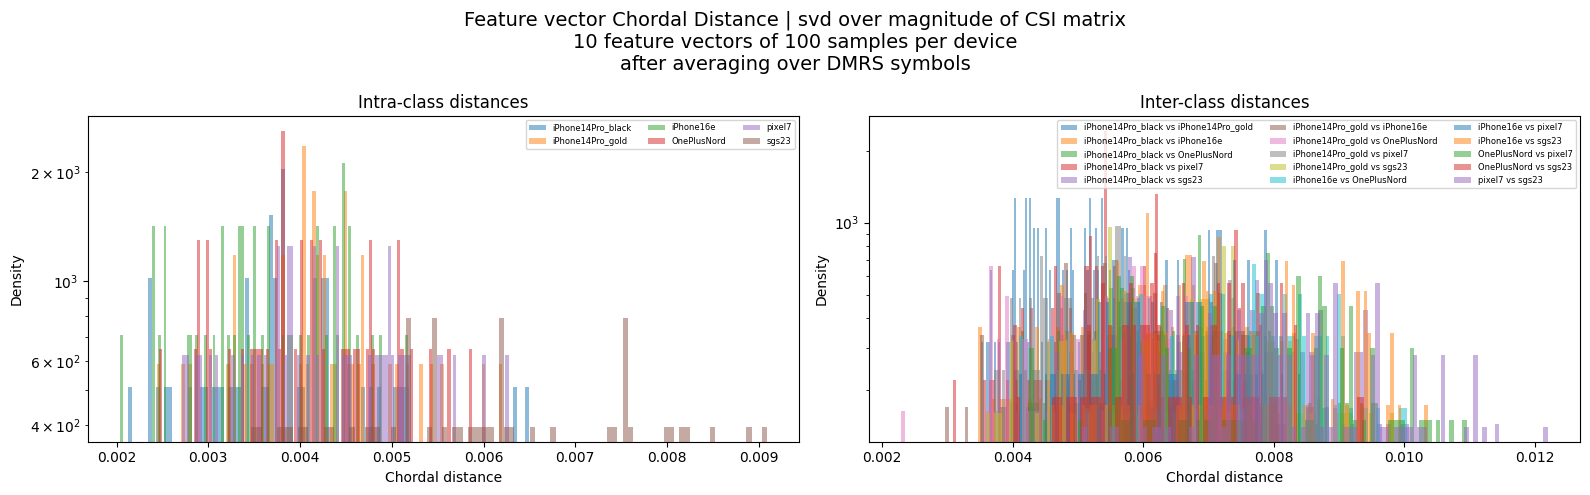

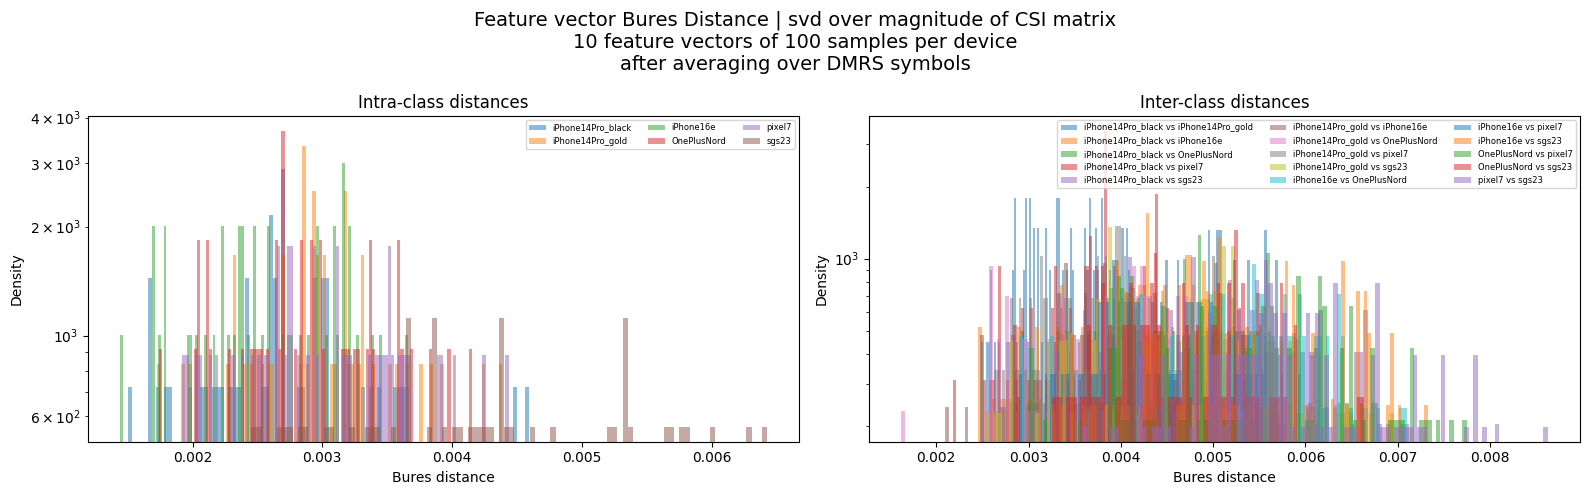

In [24]:
# PLOT RF-FINGERPRINT HISTOGRAMS

n_bins = 100  # adjust as needed

assert global_features.shape == (len(LABELS)*N_CONSECTUIVE_RANDOM_BATCHES, n_tx_ant * n_prbs * 12), "global_features shape mismatch"
all_distances = compute_distance_matrices(global_features)

for metric_name, D_metric in all_distances.items():
    intra, inter = extract_class_distances(D_metric, global_labels, LABELS)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plt.title(f"Feature vector distance histograms of {', '.join(LABELS)} with {N_PICKLES_PER_LABEL} samples each")
    fig.suptitle(f"Feature vector {metric_name} Distance | svd over magnitude of CSI matrix\n"
                 f"{N_CONSECTUIVE_RANDOM_BATCHES} feature vectors of {N_PICKLES_PER_LABEL} samples per device\n"
                 f"after averaging over DMRS symbols", fontsize=14)

    # --- Intra-class histograms (overlaid) ---
    ax = axes[0]
    for label_name, dists in intra.items():
        ax.hist(dists, bins=n_bins, alpha=0.5, density=True, label=label_name)
    ax.set_xlabel(f'{metric_name} distance')
    ax.set_ylabel('Density')
    ax.set_title('Intra-class distances')
    ax.legend(fontsize=6, ncol=3)
    ax.set_yscale('log')

    # --- Inter-class histograms (overlaid) ---
    ax = axes[1]
    for (li, lj), dists in inter.items():
        bin_edges = n_bins
        ax.hist(dists, bins=bin_edges, alpha=0.5, density=True, label=f'{li} vs {lj}')
    ax.set_xlabel(f'{metric_name} distance')
    ax.set_ylabel('Density')
    ax.set_title('Inter-class distances')
    ax.legend(fontsize=6, ncol=3)
    ax.set_yscale('log')
    plt.savefig(f"{metric_name}_{N_CONSECTUIVE_RANDOM_BATCHES}_feature_vector_distance_histograms_{len(LABELS)}_devices_{N_PICKLES_PER_LABEL}_{SELECTION_STRATEGY}_samples.png", dpi=300, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

In [9]:
# PREPARE RAW CSI SAMPLES FOR SAMMON'S MAPPING

# COMPUTE PAIRWISE L2 DISTANCE MATRIX BETWEEN SAMPLES (EACH SAMPLE CORRESPONDS TO ONE FEATURE VECTOR)

assert global_features.shape == (len(LABELS)*N_CONSECTUIVE_RANDOM_BATCHES, n_tx_ant * n_prbs * 12), "global_features shape mismatch"
# global_features has dims [len(LABELS)*N_PICKLES_PER_LABEL, n_prbs*12] and is averaged over n_dmrs_symbols
D_raw = compute_distance_matrices(global_features)
D_raw_l2 = D_raw['L2']
D_raw_cosine = D_raw['Cosine']
D_raw_chordal = D_raw['Chordal']
D_raw_bures = D_raw['Bures']

# D includes all distances, some of which are featured multiple times

L2 distance shape: (60, 60)


In [20]:
# TRANSFER D TO MATLAB FOR SAMMON'S MAPPING

scratch_dir = Path('/scratch/bsc26f18/sammon_scratch')
scratch_dir.mkdir(parents=True, exist_ok=True)

no_dims = 2

d_cov = np.asarray(D_raw_chordal, dtype=np.float64)  # MATLAB will read this as double
out_mat = scratch_dir / f"d_cov.mat"
sc.io.savemat(out_mat, {"d_cov": d_cov, "no_dims": int(no_dims)})
print("Wrote:", out_mat)

Wrote: /scratch/bsc26f18/sammon_scratch/d_cov.mat


In [21]:
# READ MATLAB MAPPEDX FILES

mat_file = scratch_dir / f"mappedX.mat"
if not mat_file.exists():
    raise FileNotFoundError(f"Mat file {mat_file} does not exist")
mappedX = sc.io.loadmat(mat_file)['mappedX']

# sammon_results has shape (2, len(LABELS)*N_CONSECTUIVE_RANDOM_BATCHES)
sammon_results = mappedX.T

S1 = sammon_results[0,:]
S2 = sammon_results[1,:]

print(f"mat_file_path: {mat_file}")
print(f"mappedX shape: {mappedX.shape}")
print(f"sammon_results shape: {sammon_results.shape}")

mat_file_path: /scratch/bsc26f18/sammon_scratch/mappedX.mat
mappedX shape: (60, 2)
sammon_results shape: (2, 60)


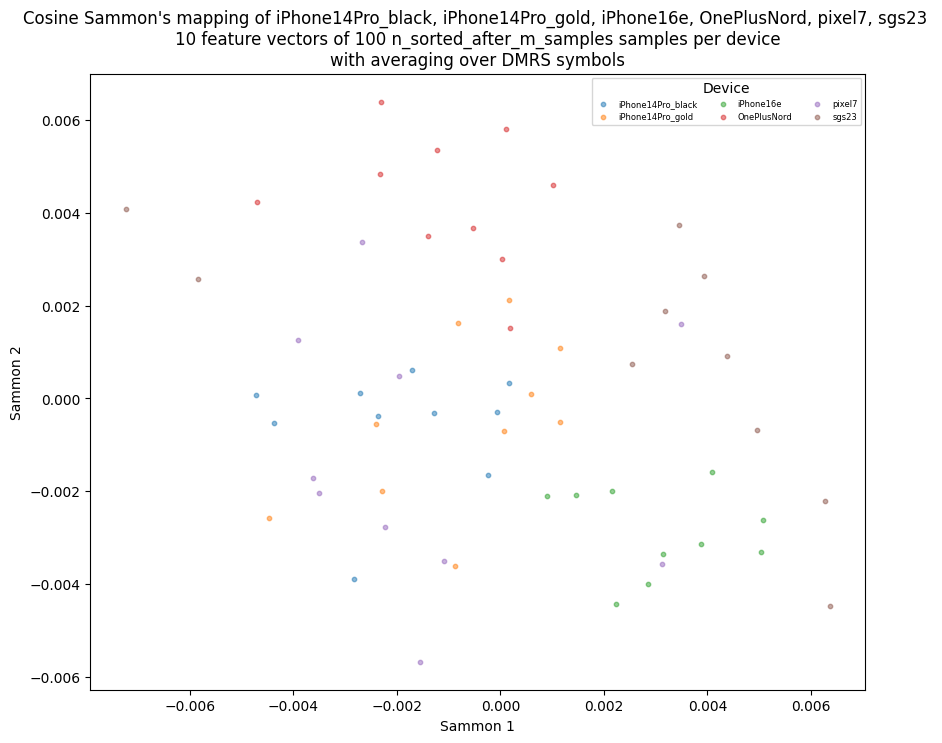

In [22]:
# PLOT SAMMON'S MAPPING RESULTS

plt.figure(figsize=(10, 8))

for label in device_ids:
    # Create a boolean mask for where the global_labels match the current device
    label_mask = (global_labels == label)

    # Scatter plot ONLY the points where the mask is True
    plt.scatter(
        S1[label_mask], 
        S2[label_mask], 
        label=LABELS[label], 
        alpha=0.5, 
        s=10  # Smaller dot size helps when plotting thousands of overlapping points
    )

plt.xlabel('Sammon 1')
plt.ylabel('Sammon 2')
plt.legend(title='Device', fontsize=6, ncol=3)
plt.title(f"Cosine Sammon's mapping of {', '.join(LABELS)} \n"
          f"{N_CONSECTUIVE_RANDOM_BATCHES} feature vectors of {N_PICKLES_PER_LABEL} {SELECTION_STRATEGY} samples per device\n"
          f"with averaging over DMRS symbols")

#plt.savefig(f"Sammon_mapping_Cosine_{N_CONSECTUIVE_RANDOM_BATCHES}_feature_vectors_of_{N_PICKLES_PER_LABEL}_{SELECTION_STRATEGY}_samples_per_device.png", dpi=300, bbox_inches='tight')

plt.show()